# EE446 - TinyML - Assignment 2

## Importing Libraries

In [94]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

## Reading Data

In [95]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [96]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [97]:
data.drop(['land', 'urgent', 'numfailedlogins', 'numoutboundcmds'], axis=1, inplace=True)

##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [98]:
data.loc[data['attack'] != 'normal', 'attack'] = 'attack'

In [99]:
data #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [100]:
label_encoder = LabelEncoder()
categorical_cols = ['protocoltype', 'service', 'flag', 'attack']
for col in categorical_cols:
    data[col] = label_encoder.fit_transform(data[col])

In [101]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [102]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

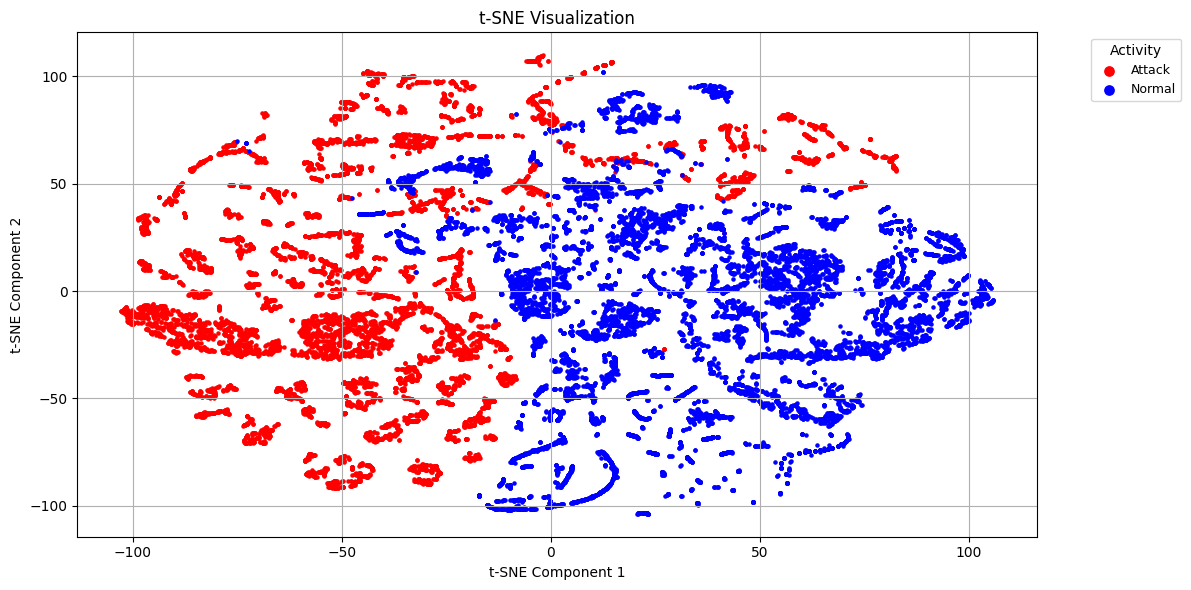

In [103]:
from sklearn.manifold import TSNE
y_vis = y_test.flatten()

# Create color maps
label_map = {0: 'Attack', 1: 'Normal'}
colors = {0: 'red', 1: 'blue'}
unique_vis_labels = sorted(np.unique(y_vis))

# Helper function for plotting the projections
def plot_2d_projection(X_proj, title, xlabel, ylabel):
    plt.figure(figsize=(12, 6))

    for label in unique_vis_labels:
        idx = y_vis == label
        plt.scatter(
            X_proj[idx, 0],
            X_proj[idx, 1],
            s=5,
            color=colors[label],
            label=label_map[label],
        )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(markerscale=3, fontsize=9, title="Activity", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# t-sne arguments
tsne_kwargs = dict(
    n_components=2,
    perplexity=30,
    learning_rate=300,
    random_state=42,
    n_jobs=-1
)
tsne = TSNE(**tsne_kwargs)
X_tsne = tsne.fit_transform(X_test)

plot_2d_projection(X_tsne, "t-SNE Visualization", "t-SNE Component 1", "t-SNE Component 2")

##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

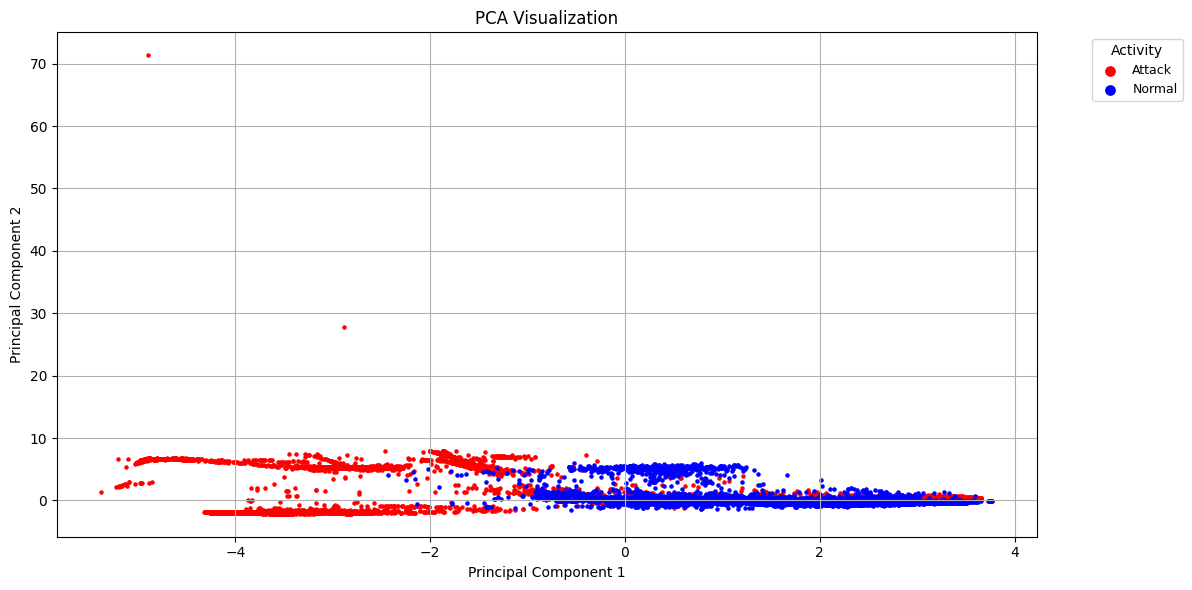

In [104]:
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X_test)
plot_2d_projection(X_pca, "PCA Visualization", "Principal Component 1", "Principal Component 2")

##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

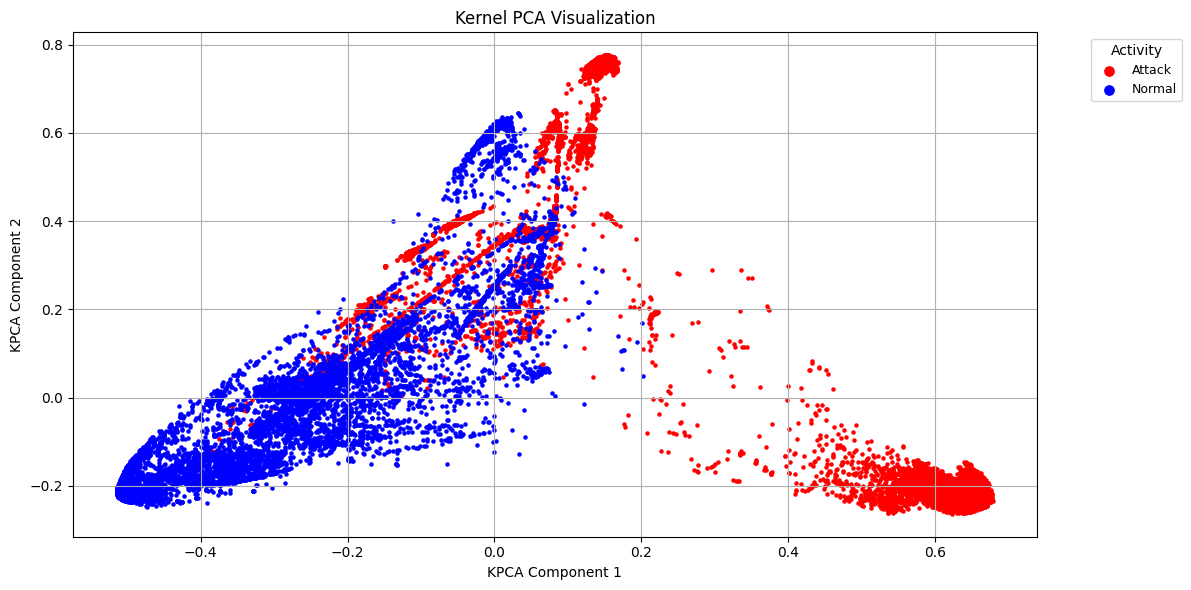

In [105]:
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(n_components=2, kernel='rbf')
X_kpca = kpca.fit_transform(X_test)
plot_2d_projection(X_kpca, "Kernel PCA Visualization", "KPCA Component 1", "KPCA Component 2")

## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure to include two neurons and softmax activation in the output layer of your DNN.

In [106]:
# Define the DNN model
base_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(2, activation='softmax')], name='base_model')

##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [107]:
base_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Adjust training parameters compared to other assignments because there are a lot of samples
history_baseline = base_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
)

Epoch 1/10
1418/1418 [==============================] - 1s 457us/step - loss: 0.0370 - accuracy: 0.9872 - val_loss: 0.0101 - val_accuracy: 0.9956
Epoch 2/10
1418/1418 [==============================] - 1s 428us/step - loss: 0.0079 - accuracy: 0.9967 - val_loss: 0.0055 - val_accuracy: 0.9980
Epoch 3/10
1418/1418 [==============================] - 1s 426us/step - loss: 0.0064 - accuracy: 0.9976 - val_loss: 0.0056 - val_accuracy: 0.9975
Epoch 4/10
1418/1418 [==============================] - 1s 427us/step - loss: 0.0063 - accuracy: 0.9979 - val_loss: 0.0050 - val_accuracy: 0.9980
Epoch 5/10
1418/1418 [==============================] - 1s 425us/step - loss: 0.0043 - accuracy: 0.9985 - val_loss: 0.0034 - val_accuracy: 0.9983
Epoch 6/10
1418/1418 [==============================] - 1s 428us/step - loss: 0.0039 - accuracy: 0.9985 - val_loss: 0.0035 - val_accuracy: 0.9986
Epoch 7/10
1418/1418 [==============================] - 1s 424us/step - loss: 0.0041 - accuracy: 0.9985 - val_loss: 0.0035 -

##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

788/788 [==============================] - 0s 253us/step - loss: 0.0063 - accuracy: 0.9984
Accuracy 0.9983726739883423
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11695
           1       1.00      1.00      1.00     13500

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



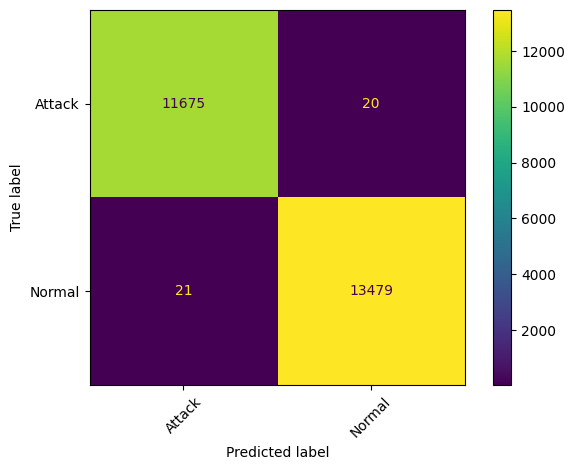

In [108]:
# Classification Report
y_prediction_probabilities = base_model.predict(X_test)
y_predictions = np.argmax(y_prediction_probabilities, axis=1)
_, accuracy = base_model.evaluate(X_test, y_test)
print("Accuracy",accuracy)
print("Classification Report")
print(classification_report(y_test, y_predictions))

# Confusion matrix
cm = confusion_matrix(y_test, y_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Attack', 'Normal'])
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()

In [109]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement Dynamic Range Quantization on the base_model. Designate the resulting quantized ML model as tflite_quant_model.

In [110]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp8k95876t/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp8k95876t/assets
2026-05-10 20:54:50.883923: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-10 20:54:50.883939: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-10 20:54:50.884059: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp8k95876t
2026-05-10 20:54:50.884505: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-10 20:54:50.884510: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmp8k95876t
2026-05-10 20:54:50.885825: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-10 20:54:50.904642: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmphyugp4wk/assets


INFO:tensorflow:Assets written to: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmphyugp4wk/assets


int8 model size: 8.33 KB


2026-05-10 21:05:04.162534: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-10 21:05:04.162548: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-10 21:05:04.162646: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmphyugp4wk
2026-05-10 21:05:04.163078: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-10 21:05:04.163082: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmphyugp4wk
2026-05-10 21:05:04.164204: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-10 21:05:04.182680: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/wt/0j3w1fqn0g7925lwmgq8mfp40000gn/T/tmphyugp4wk
2026-05-

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     11695
           1       0.99      1.00      0.99     13500

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195



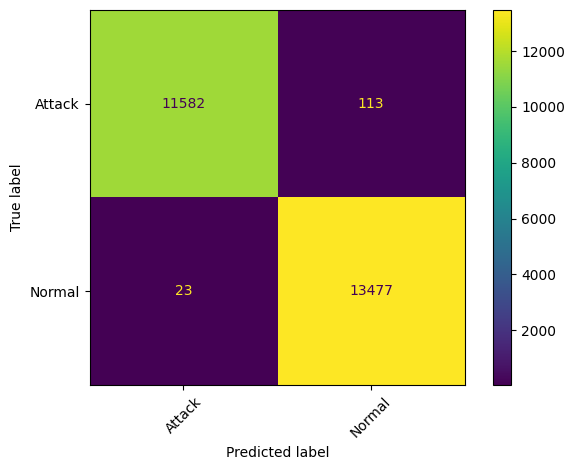

In [116]:
# Part of Question 4
# This cell quantizes the base model into int8, evaluates the quantized model, and saves to a header file so it can run on the Arduino

# Generate representative dataset
def representative_data_gen(X_reference, num_samples=500):
    """Create a representative dataset generator for full integer quantization."""
    max_samples = min(num_samples, len(X_reference))
    for i in range(max_samples):
        yield [X_reference[i:i + 1].astype(np.float32)]
def get_representative_data():
    return representative_data_gen(X_train)

# Convert to int8
converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = get_representative_data
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
int8_model = converter.convert()

# Save int8 tflite model
with open('int8_model.tflite', 'wb') as f:
    f.write(int8_model)
int8_model_size = os.path.getsize('int8_model.tflite')
print(f"int8 model size: {int8_model_size / 1024:.2f} KB")

# Evaulate int8 model
interpreter = tf.lite.Interpreter(model_content=int8_model)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]
input_scale, input_zero_point = input_details["quantization"]
output_scale, output_zero_point = output_details["quantization"]

y_pred = []
# Dequantize
for i in range(len(X_test)):
    x = X_test[i:i+1].astype(np.float32)
    x = np.round(x/input_scale + input_zero_point).astype(np.int8)
    interpreter.set_tensor(input_details["index"], x)
    interpreter.invoke()
    
    output = interpreter.get_tensor(output_details["index"])
    output = (output.astype(np.float32) - output_zero_point) * output_scale
    y_pred.append(np.argmax(output))
y_pred = np.array(y_pred)

# Classification Report
print("Classification Report")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Attack', 'Normal'])
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()

# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in int8_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

#Writing to the header file
with open('network_model_int8.h', 'w') as file:
    file.write(header_str)

In [112]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 98.15 KB
Quantized model size: 9.56 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11695
           1       1.00      1.00      1.00     13500

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



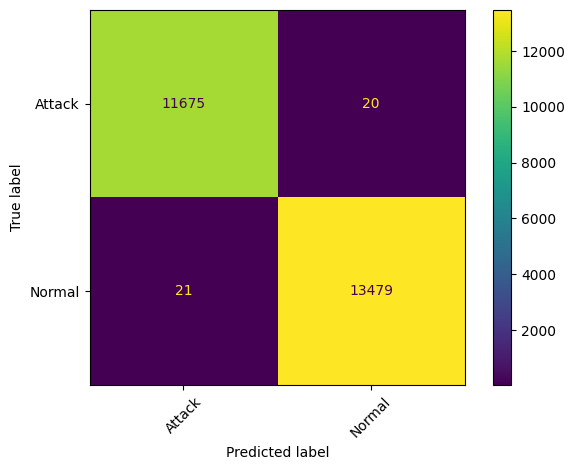

In [113]:
# Evaluate dynamic model
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

y_pred_quantized = []
for i in range(len(X_test)):
    input_data = np.array([X_test[i]], dtype=np.float32)
    interpreter.set_tensor(input_details['index'], input_data)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details['index'])
    y_pred_quantized.append(np.argmax(output))

y_pred_quantized=np.array(y_pred_quantized)

# Classification Report
print("Classification Report")
print(classification_report(y_test, y_pred_quantized))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_quantized)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Attack', 'Normal'])
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()

## Question 5: Converting tflite_model to C and create the header file

In [114]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [115]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Question 5: Generating Samples for Inference on Arduino

In [93]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare

Xtest = X_test[6:156,:]
print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 150;
const unsigned int X_test_dim2 = 38;

const float X_test[150][38] = {
    -0.11024922321249885, -2.468724163053645, -1.05383839089509, 
    0.7511112872365361, -0.007760877950036992, -0.004918644383724874, 
    -0.08948642202040107, -0.09507567152556495, -0.8092618187059747, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.7257784945454897, -0.21666922031567779, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, 3.4741184775599305, 
    -1.8159110618054883, -0.6111255516823535, 1.0664013456654926, 
    -0.43907816809041417, 2.756092007079775, 4.152839416895877, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, -1.09276330835188, -0.110249223212498

In [92]:
ytest=y_test[6:16]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 10;
const unsigned int y_test_dim2 = 1;

const uint8_t y_test[10][1] = {
    0, 1, 0, 1, 1, 1, 1, 0, 0, 0
};

